
📊 Top labels:
                              Label  Frequency
0               LowSpiritRecordings         16
1                     KontorRecords         15
2                       ArmadaMusic          9
3                        ArminAudio          8
4                      TigerRecords          7
5  InternationalDeejayGigoloRecords          6
6                        GreatStuff          6
7                TraumSchallplatten          6
8                          Drumcode          6
9                     NouveauNiveau          6
Epoch 1/300


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3773 - mae: 0.5264 - val_loss: 0.1048 - val_mae: 0.3007
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.3545 - mae: 0.5075 - val_loss: 0.1025 - val_mae: 0.2978
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.3363 - mae: 0.4924 - val_loss: 0.0993 - val_mae: 0.2936
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3230 - mae: 0.4817 - val_loss: 0.0957 - val_mae: 0.2883
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3083 - mae: 0.4665 - val_loss: 0.0913 - val_mae: 0.2817
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2919 - mae: 0.4513 - val_loss: 0.0868 - val_mae: 0.2747
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2836 - mae: 0.4436 - val_loss: 0.0820 - val_mae: 0.2668
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2693 - mae: 0.4293 - val_loss: 0.0770 - val_mae: 0.2583
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2551 - mae: 0.4163 - val_l

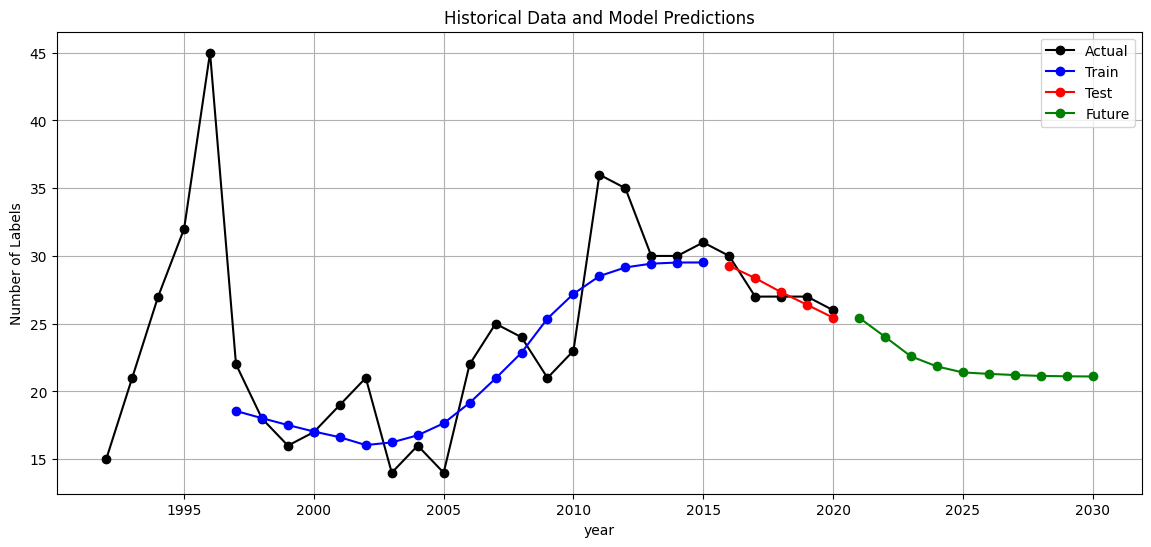

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import Counter

# =========================
# 1. 读取数据
# =========================
df = pd.read_csv('number-of-labels.csv')
df = df.sort_values('year').reset_index(drop=True)

# =========================
# 2. label统计
# =========================
label_freq = Counter(",".join(df['record_labels'].astype(str)).replace(" ", "").split(","))
label_freq = pd.DataFrame(label_freq.most_common(), columns=['Label', 'Frequency'])

print("\n📊 Top labels:")
print(label_freq.head(10))

# =========================
# 3. 时间特征
# =========================
min_year = df['year'].min()
df['year_norm'] = (df['year'] - min_year) / (df['year'].max() - min_year)

df['year_sin'] = np.sin(2 * np.pi * df['year_norm'])
df['year_cos'] = np.cos(2 * np.pi * df['year_norm'])

# =========================
# 4. 特征定义
# =========================
features = ['number_of_labels', 'year_sin', 'year_cos']
target = 'number_of_labels'

# =========================
# 5. 标准化
# =========================
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

# =========================
# 6. 序列构建
# =========================
def create_sequences(data, features, target, seq_length=5):
    X, y = [], []
    values = data[features].values
    target_values = data[target].values

    for i in range(seq_length, len(data)):
        X.append(values[i-seq_length:i])
        y.append(target_values[i])

    return np.array(X), np.array(y)

seq_length = 5
X, y = create_sequences(df_scaled, features, target, seq_length)

# =========================
# 7. train/test split
# =========================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =========================
# 8. LSTM模型
# =========================
def build_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model((X.shape[1], X.shape[2]))

early_stop = EarlyStopping(patience=30, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=300,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. 预测
# =========================
train_pred = model.predict(X_train).flatten()
test_pred = model.predict(X_test).flatten()

# 反归一化
y_train_real = scaler.inverse_transform(
    np.column_stack([y_train, np.zeros((len(y_train),2))])
)[:,0]

y_test_real = scaler.inverse_transform(
    np.column_stack([y_test, np.zeros((len(y_test),2))])
)[:,0]

train_pred_real = scaler.inverse_transform(
    np.column_stack([train_pred, np.zeros((len(train_pred),2))])
)[:,0]

test_pred_real = scaler.inverse_transform(
    np.column_stack([test_pred, np.zeros((len(test_pred),2))])
)[:,0]

# =========================
# 10. 模型评估
# =========================
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MSE={mse:.2f}, MAE={mae:.2f}, R²={r2:.2f}")

print("\n📊 Model Evaluation")
evaluate(y_train_real, train_pred_real, "Train Set")
evaluate(y_test_real, test_pred_real, "Test Set")

# =========================
# 11. 历史真实数据
# =========================
print("\n📊 Number of labels per year (historical):")
for _, row in df.iterrows():
    print(f"{int(row['year'])}: {int(row['number_of_labels'])} labels")

# =========================
# 12. 未来预测
# =========================
def future_predict(model, last_seq, steps=10):
    seq = last_seq.copy()
    future = []

    for _ in range(steps):
        pred = model.predict(seq.reshape(1, *seq.shape), verbose=0)[0][0]
        future.append(pred)

        new_row = seq[-1].copy()
        new_row[0] = pred
        new_row[1] *= 0.99
        new_row[2] *= 0.99

        seq = np.vstack([seq[1:], new_row])

    return np.array(future)

future = future_predict(model, X[-1], 10)

# 反归一化未来值
future_real = scaler.inverse_transform(
    np.column_stack([future, np.zeros((len(future),2))])
)[:,0]

future_real = np.clip(future_real, 1, None)

# =========================
# 13. 未来年份
# =========================
future_years = range(df['year'].max()+1, df['year'].max()+11)

print("\n📈 Future Predictions:")
for y, v in zip(future_years, future_real):
    print(f"{y}: {v:.1f} labels")

# =========================
# 14. 可视化
plt.figure(figsize=(14,6))

plt.plot(df['year'], df['number_of_labels'],
         'ko-', label='Actual')

plt.plot(df['year'].iloc[seq_length:seq_length+len(train_pred_real)],
         train_pred_real, 'bo-', label='Train')

plt.plot(df['year'].iloc[seq_length+len(train_pred_real):
                          seq_length+len(train_pred_real)+len(test_pred_real)],
         test_pred_real, 'ro-', label='Test')

plt.plot(future_years, future_real,
         'go-', label='Future')

# 坐标轴
plt.xlabel("year")
plt.ylabel("Number of Labels")

# 标题
plt.title("Historical Data and Model Predictions")

plt.legend()
plt.grid()

plt.show()
